# 🎸 Guitar Pedal Effects on NTSC Analog Signal

What happens if you run an NTSC TV signal through a guitar gain pedal?

## How NTSC turns a picture into a signal

A digital image is a 2D grid of pixels — all present at once. An NTSC signal is **temporal**: it paints the image one line at a time, top to bottom, as a continuous 1D waveform over time.

Here's how a single frame becomes a signal:

```
2D Image (e.g. 640×480)          NTSC Analog Signal (1D over time)
┌─────────────────────┐
│ line 0 ─────────────│──→  [sync][burst][pixel pixel pixel...]  ← scan line 0
│ line 1 ─────────────│──→  [sync][burst][pixel pixel pixel...]  ← scan line 1
│ line 2 ─────────────│──→  [sync][burst][pixel pixel pixel...]  ← scan line 2
│         ...         │          ...
│ line 261 ───────────│──→  [sync][burst][pixel pixel pixel...]  ← scan line 261
└─────────────────────┘
                              ◀──────── time ────────────▶
```

Each scan line is a short burst of signal (~63.5 µs) that encodes:
- A **sync pulse** (tells the TV "new line starts here")
- A **color burst** (phase reference for decoding color)
- The **video data** — brightness (luma) as amplitude, color (chroma) as a 3.58 MHz wave mixed on top

The full frame is 262 lines × 910 samples/line = **238,420 signal samples**. In our code, this is a `(262, 910)` int8 array where each value represents the signal level in IRE units:
- **-40**: sync tip (below black — the TV uses this for timing, not display)
- **0**: blanking level  
- **~7**: black level
- **~100**: peak white

## What this notebook does

1. Loads 3 seconds of video
2. Encodes each frame into a real NTSC analog signal via `crt.modulate()`
3. Applies guitar pedal-style effects (overdrive, distortion, fuzz) to the raw analog waveform
4. Decodes the mangled signal back to an image via `crt.demodulate()`
5. Writes out the result as a video

Because the signal is temporal and 1D (just like audio), we can treat it exactly like a guitar signal and run it through gain stages, clipping, and tone filters. The interesting part is that distortion doesn't just affect brightness — it creates **intermodulation products** that interfere with the color carrier, producing color artifacts that are the visual equivalent of harmonic distortion in audio.

In [1]:
import os, sys
import numpy as np
import cv2
from scipy import signal as sp_signal
import matplotlib.pyplot as plt
from IPython.display import Video, display

# Add python bindings to path
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(REPO_ROOT, "python"))

from ntsc_crt import CRT, PIX_FORMAT_BGRA

%matplotlib inline

## Load 3 seconds of video

In [2]:
VIDEO_PATH = os.path.join(REPO_ROOT, "examples", "00029.mp4")
DURATION_SEC = 3

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(fps * DURATION_SEC)

frames = []
for _ in range(n_frames):
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2BGRA))
cap.release()

h, w = frames[0].shape[:2]
print(f"Loaded {len(frames)} frames @ {fps:.2f} FPS, {w}x{h}")
print(f"Duration: {len(frames)/fps:.2f}s")

Loaded 179 frames @ 59.94 FPS, 1920x1080
Duration: 2.99s


## Guitar Pedal Signal Processing Functions

A guitar signal chain works like this:
1. **Gain stage** — amplify the signal beyond its normal range
2. **Clipping stage** — the signal hits the rails and gets clipped (this IS the distortion)
3. **Tone filter** — a low-pass filter to tame harsh harmonics from the clipping

We'll apply the same thing to the NTSC analog signal. The signal is int8 (-128 to 127), with the actual video content in roughly -40 to +110 IRE.

### Three pedal types:
- **Overdrive (soft clip)** — `tanh()` saturation, warm tube-like compression
- **Distortion (hard clip)** — square-wave clipping, aggressive transistor sound
- **Fuzz (asymmetric clip)** — different positive/negative thresholds + signal folding

In [3]:
def normalize_signal(sig):
    """Convert int8 NTSC signal to float [-1, 1] range for DSP."""
    return sig.astype(np.float64) / 127.0

def denormalize_signal(sig_f):
    """Convert float [-1, 1] back to int8 for the CRT buffer."""
    return np.clip(sig_f * 127.0, -128, 127).astype(np.int8)

# --- Clipping stages ---

def overdrive(signal_f, gain=4.0):
    """Soft clipping via tanh — warm tube-like saturation.
    Higher gain = more compression/saturation."""
    return np.tanh(gain * signal_f)

def distortion(signal_f, gain=8.0, threshold=0.8):
    """Hard clipping — aggressive transistor distortion.
    Signal is amplified then brick-wall limited."""
    driven = gain * signal_f
    return np.clip(driven, -threshold, threshold) / threshold

def fuzz(signal_f, gain=12.0, pos_thresh=0.6, neg_thresh=-0.9):
    """Asymmetric fuzz — different clip levels for positive/negative.
    Adds even harmonics (asymmetry) + octave-up via full-wave rectification."""
    driven = gain * signal_f
    # Asymmetric clip
    clipped = np.where(driven > 0,
                       np.minimum(driven, pos_thresh) / pos_thresh,
                       np.maximum(driven, neg_thresh) / abs(neg_thresh))
    # Blend in octave-up (full-wave rectification)
    octave = np.abs(clipped) * 2 - 1
    return 0.7 * clipped + 0.3 * octave

# --- Tone control ---

def tone_filter(signal_f, cutoff=0.3, order=4):
    """Low-pass filter to tame harsh harmonics.
    cutoff: 0.01 (dark/muffled) to 1.0 (wide open, all harmonics).
    Applied per scan line."""
    cutoff = np.clip(cutoff, 0.01, 0.99)
    sos = sp_signal.butter(order, cutoff, btype='low', output='sos')
    if signal_f.ndim == 2:
        out = np.empty_like(signal_f)
        for i in range(signal_f.shape[0]):
            out[i] = sp_signal.sosfilt(sos, signal_f[i])
        return out
    return sp_signal.sosfilt(sos, signal_f)

# --- Full pedal chain ---

def pedal_chain(signal_int8, pedal_type="overdrive", gain=4.0, tone_cutoff=0.5):
    """Full guitar pedal: gain → clipping → tone → output.
    
    Args:
        signal_int8: (262, 910) int8 NTSC analog signal
        pedal_type: "overdrive", "distortion", or "fuzz"
        gain: amplification factor (1-50)
        tone_cutoff: low-pass filter cutoff (0.01-0.99), 1.0 = bypass
    Returns:
        Modified (262, 910) int8 signal
    """
    sig = normalize_signal(signal_int8)
    
    # Gain + clipping stage
    if pedal_type == "overdrive":
        sig = overdrive(sig, gain)
    elif pedal_type == "distortion":
        sig = distortion(sig, gain)
    elif pedal_type == "fuzz":
        sig = fuzz(sig, gain)
    
    # Tone control (skip if wide open)
    if tone_cutoff < 0.99:
        sig = tone_filter(sig, tone_cutoff)
    
    return denormalize_signal(sig)

print("Pedal functions defined ✓")

Pedal functions defined ✓


## Visualize the transfer curves

These show what each pedal does to the signal — the X axis is input amplitude, Y axis is output. A straight diagonal line = no effect. Curves/clipping = distortion.

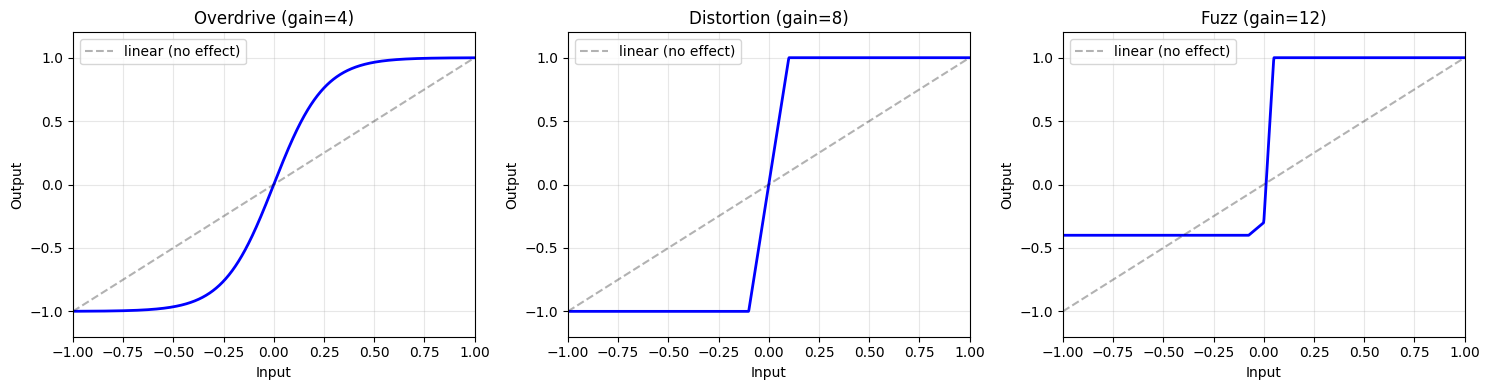

In [4]:
x = np.linspace(-1, 1, 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, fn, kwargs) in zip(axes, [
    ("Overdrive (gain=4)", overdrive, dict(gain=4)),
    ("Distortion (gain=8)", distortion, dict(gain=8)),
    ("Fuzz (gain=12)", fuzz, dict(gain=12)),
]):
    y = fn(x, **kwargs)
    ax.plot(x, y, 'b-', linewidth=2)
    ax.plot(x, x, 'k--', alpha=0.3, label='linear (no effect)')
    ax.set_title(name)
    ax.set_xlabel('Input')
    ax.set_ylabel('Output')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1.2, 1.2)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Preview: Single frame through each pedal

Encode one frame, apply each pedal, decode, and compare side by side.

In [5]:
def process_frame_with_pedal(crt, frame, pedal_type="overdrive", gain=4.0, tone_cutoff=0.5):
    """Modulate → apply pedal to analog signal → demodulate."""
    crt.modulate(frame, field=0, frame=0, in_format=PIX_FORMAT_BGRA)
    
    raw_signal = crt.get_analog_signal()
    modified = pedal_chain(raw_signal, pedal_type, gain, tone_cutoff)
    crt.set_analog_signal(modified)
    
    return crt.demodulate(noise=0), raw_signal, modified

# Process a single test frame with each pedal type
test_frame = frames[0]
crt = CRT("ntsc", out_w=w, out_h=h, out_format=PIX_FORMAT_BGRA)
crt.blend = False  # No blending for single-frame preview

results = {}
for pedal in ["overdrive", "distortion", "fuzz"]:
    out, raw, mod = process_frame_with_pedal(crt, test_frame, pedal, gain=6.0, tone_cutoff=0.4)
    results[pedal] = (out, raw, mod)

# Also get a clean decode for comparison
crt.modulate(test_frame, field=0, frame=0, in_format=PIX_FORMAT_BGRA)
clean_output = crt.demodulate(noise=0)

print("Single-frame preview ready ✓")

Single-frame preview ready ✓


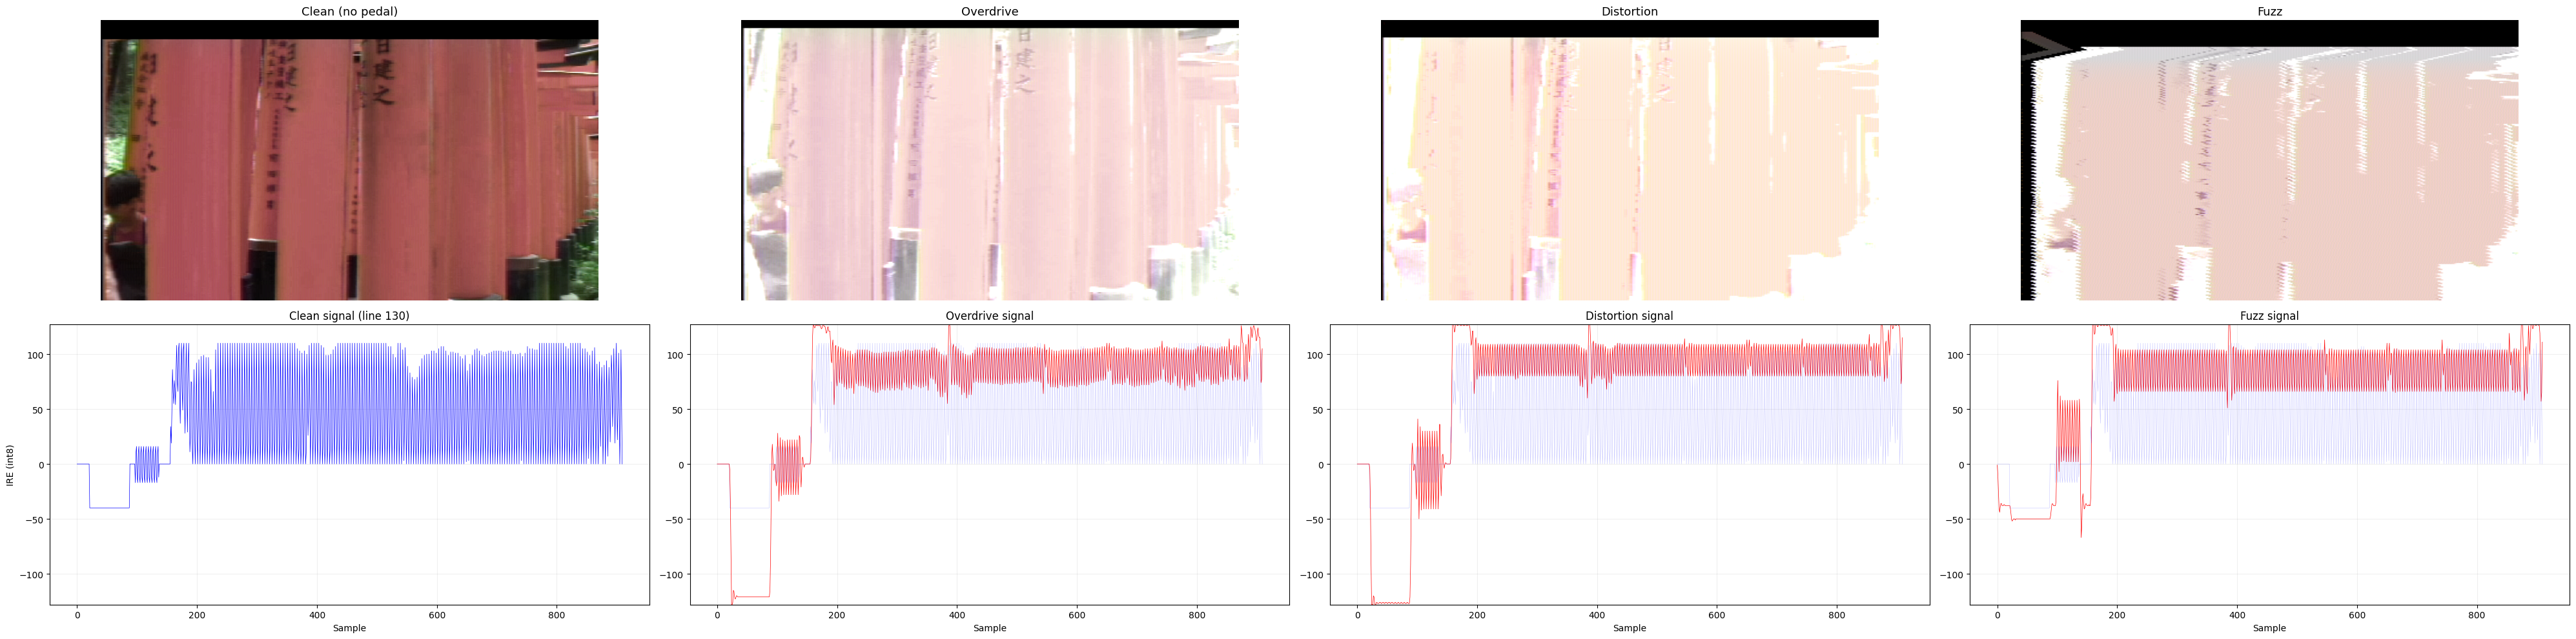

In [14]:
# Compare all pedal outputs side by side
fig, axes = plt.subplots(2, 4, figsize=(40, 10))

# Top row: decoded images
def show_bgra(ax, img, title):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGRA2RGB))
    ax.set_title(title, fontsize=13)
    ax.axis('off')

show_bgra(axes[0, 0], clean_output, "Clean (no pedal)")
for i, pedal in enumerate(["overdrive", "distortion", "fuzz"]):
    show_bgra(axes[0, i+1], results[pedal][0], pedal.capitalize())

# Bottom row: analog signal waveforms (scan line 130 = middle of screen)
LINE = 130
_, raw_sig, _ = results["overdrive"]

axes[1, 0].plot(raw_sig[LINE], 'b-', linewidth=0.5)
axes[1, 0].set_title("Clean signal (line 130)")
axes[1, 0].set_ylim(-128, 127)
axes[1, 0].set_ylabel("IRE (int8)")

for i, pedal in enumerate(["overdrive", "distortion", "fuzz"]):
    _, _, mod_sig = results[pedal]
    axes[1, i+1].plot(mod_sig[LINE], 'r-', linewidth=0.5)
    axes[1, i+1].plot(raw_sig[LINE], 'b-', linewidth=0.3, alpha=0.3)
    axes[1, i+1].set_title(f"{pedal.capitalize()} signal")
    axes[1, i+1].set_ylim(-128, 127)

for ax in axes[1]:
    ax.set_xlabel("Sample")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Frequency spectrum: what clipping does to the signal

Clipping introduces new harmonics — this is the "character" of distortion. Let's look at the frequency content of scan line 130 before and after each pedal.

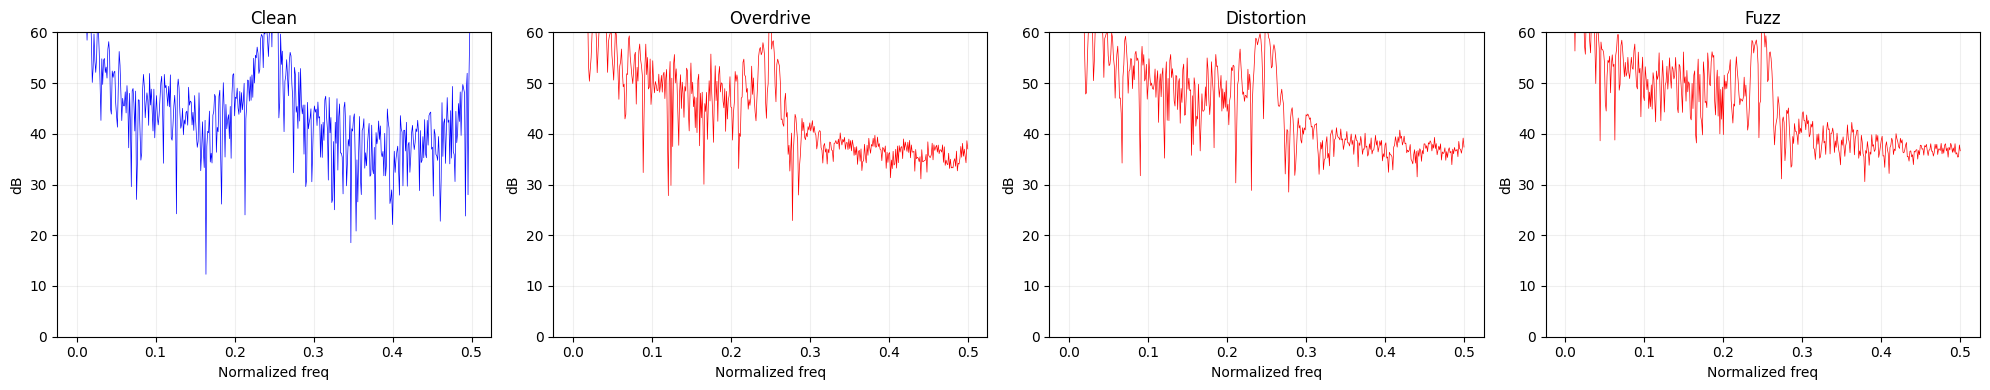

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

_, raw_sig, _ = results["overdrive"]
clean_line = raw_sig[LINE].astype(np.float64)
freqs = np.fft.rfftfreq(len(clean_line))

def plot_spectrum(ax, line, title, color='b'):
    spectrum = np.abs(np.fft.rfft(line))
    spectrum_db = 20 * np.log10(spectrum + 1e-10)
    ax.plot(freqs, spectrum_db, color=color, linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel("Normalized freq")
    ax.set_ylabel("dB")
    ax.set_ylim(0, 60)
    ax.grid(True, alpha=0.2)

plot_spectrum(axes[0], clean_line, "Clean")
for i, pedal in enumerate(["overdrive", "distortion", "fuzz"]):
    _, _, mod_sig = results[pedal]
    plot_spectrum(axes[i+1], mod_sig[LINE].astype(np.float64), pedal.capitalize(), 'r')

plt.tight_layout()
plt.show()

## 🎛️ Tweak pedal parameters on a single frame

Change `PEDAL`, `GAIN`, `TONE`, and `FRAME_IDX` below and re-run the cell to experiment.

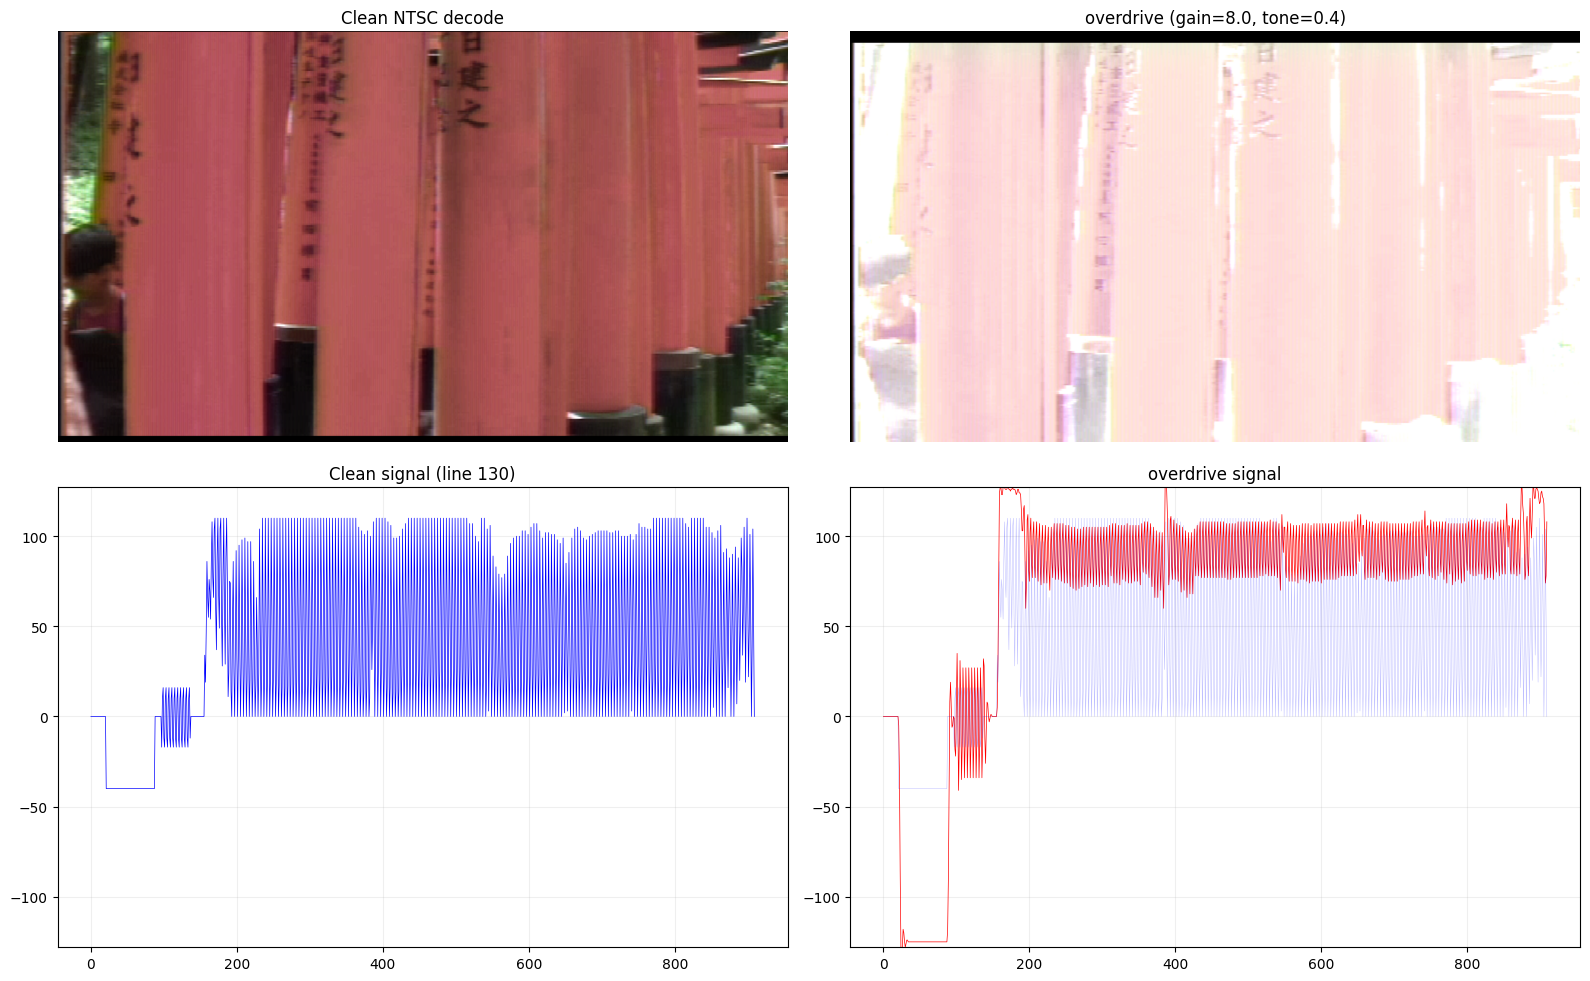

In [13]:
# ── Change these and re-run the cell to experiment ──
PEDAL = "overdrive"   # "overdrive", "distortion", or "fuzz"
GAIN = 8.            # 1.0 – 50.0
TONE = 0.4            # 0.01 (muffled) – 1.0 (bright)
FRAME_IDX = 0         # 0 – len(frames)-1

crt_tweak = CRT("ntsc", out_w=w, out_h=h, out_format=PIX_FORMAT_BGRA)
crt_tweak.blend = False

out, raw, mod = process_frame_with_pedal(crt_tweak, frames[FRAME_IDX], PEDAL, GAIN, TONE)

# Clean decode for comparison
crt_tweak.modulate(frames[FRAME_IDX], field=0, frame=0, in_format=PIX_FORMAT_BGRA)
clean = crt_tweak.demodulate(noise=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(cv2.cvtColor(clean, cv2.COLOR_BGRA2RGB))
axes[0, 0].set_title("Clean NTSC decode")
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(out, cv2.COLOR_BGRA2RGB))
axes[0, 1].set_title(f"{PEDAL} (gain={GAIN}, tone={TONE})")
axes[0, 1].axis('off')

axes[1, 0].plot(raw[LINE], 'b-', linewidth=0.5)
axes[1, 0].set_title(f"Clean signal (line {LINE})")
axes[1, 0].set_ylim(-128, 127)
axes[1, 0].grid(True, alpha=0.2)

axes[1, 1].plot(mod[LINE], 'r-', linewidth=0.5)
axes[1, 1].plot(raw[LINE], 'b-', linewidth=0.3, alpha=0.3)
axes[1, 1].set_title(f"{PEDAL} signal")
axes[1, 1].set_ylim(-128, 127)
axes[1, 1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Render full 3-second video with each pedal

Process all frames and write out comparison videos. Adjust the parameters below to taste.

In [9]:
# ── Pedal settings for video render ──
PEDAL_CONFIGS = {
    "overdrive":  dict(pedal_type="overdrive",  gain=6.0,  tone_cutoff=0.4),
    "distortion": dict(pedal_type="distortion", gain=10.0, tone_cutoff=0.3),
    "fuzz":       dict(pedal_type="fuzz",       gain=15.0, tone_cutoff=0.25),
}

OUTPUT_DIR = os.path.join(REPO_ROOT, "examples", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

for name, config in PEDAL_CONFIGS.items():
    out_path = os.path.join(OUTPUT_DIR, f"pedal_{name}.mp4")
    crt_vid = CRT("ntsc", out_w=w, out_h=h, out_format=PIX_FORMAT_BGRA)
    crt_vid.blend = False
    
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_path, fourcc, fps, (w, h))
    
    for i, frame in enumerate(frames):
        out_frame, _, _ = process_frame_with_pedal(crt_vid, frame, **config)
        writer.write(cv2.cvtColor(out_frame, cv2.COLOR_BGRA2BGR))
        
        if (i + 1) % 30 == 0:
            print(f"  {name}: {i+1}/{len(frames)} frames", end="\r")
    
    writer.release()
    print(f"✓ {name}: saved to {out_path}   ")

print("\nAll videos rendered!")

✓ overdrive: saved to /home/dupeljan/Projects/NTSC-CRT/examples/output/pedal_overdrive.mp4   
✓ distortion: saved to /home/dupeljan/Projects/NTSC-CRT/examples/output/pedal_distortion.mp4   
✓ fuzz: saved to /home/dupeljan/Projects/NTSC-CRT/examples/output/pedal_fuzz.mp4   

All videos rendered!


## What's happening?

When you run an NTSC signal through a guitar gain pedal:

1. **Overdrive** (soft clip / tanh): The signal gets compressed smoothly. Bright areas get clamped, sync pulses get squashed. The TV can still mostly decode it because the waveform shape is preserved — you get washed-out contrast and subtle color shifts.

2. **Distortion** (hard clip): The signal is amplified and brick-wall clipped. Sync pulses are obliterated (they're at -40, which gets clipped to the same level as blanking). The demodulator struggles to lock — expect horizontal tearing, color fringing, and crushed contrast.

3. **Fuzz** (asymmetric + octave): The most destructive. Positive and negative halves of the signal are clipped differently, introducing even harmonics. The octave-up effect (full-wave rectification) completely mangles the chroma subcarrier timing. Expect psychedelic color artifacts and broken sync.

The **tone knob** (low-pass filter) smooths out the harsh harmonics from clipping. Lower cutoff = more muffled/blurry, higher = sharper but noisier. On a real TV, this would affect how much chroma detail survives the distortion.

### Key insight
The NTSC color information is encoded as a 3.58 MHz carrier wave riding on top of the luminance signal. Guitar pedal distortion adds harmonics and intermodulation products that interfere with this carrier — **the color artifacts you see ARE the harmonic distortion**, just decoded as chroma instead of heard as audio.